<a href="https://colab.research.google.com/github/regmiresearch/ImageProcessingProjects/blob/main/Chapter15/TrOCR_fine_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [111]:
%%capture
!wget https://www.dropbox.com/s/l2ul3upj7dkv4ou/synthetic-data.zip
!unzip -qq synthetic-data.zip
%pip install -q datasets jiwer
%pip -q install torch_snippets torch_summary editdistance
%pip -q install accelerate

In [112]:
from torch_snippets import *
from torchsummary import summary
import editdistance

In [113]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
fname2label = lambda fname: stem(fname).split('@')[0]
images = Glob('synthetic-data/*')

In [114]:
len(images)

25132

In [115]:
images_list = []
labels_list = []
for image in images:
  images_list.append(str(image).split('/')[-1])
  labels_list.append(fname2label(image))
df = pd.DataFrame([images_list[:5000], labels_list[:5000]]).T
df.columns = ['file_name', 'text']
df.head()

,file_name,text
0,open@0UDOqi.png,open
1,her@TJ8hyY.png,her
2,language@sXp4r3.png,language
3,toward@OUXB2V.png,toward
4,soon@e42qZ3.png,soon


In [116]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.1)
train_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

In [117]:
import torch
from torch.utils.data import Dataset
from PIL import Image
# 1. Redefine the dataset class right here so Python is forced to use it
class IAMDatasetFixed(Dataset):
    def __init__(self, df, processor, root_dir, max_target_length=128):
        self.df = df
        self.processor = processor
        self.root_dir = root_dir
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        file_name = self.df.iloc[idx]['file_name']
        text = self.df.iloc[idx]['text']

        # Combine folder path with image file name
        img_path = os.path.join(self.root_dir, file_name)
        image = Image.open(img_path).convert("RGB")

        # Squeeze out the extra batch dimension from processor
        pixel_values = self.processor(image, return_tensors="pt").pixel_values.squeeze(0)

        # Tokenize text targets
        labels = self.processor.tokenizer(
            text,
            padding="do_not_pad",
            truncation=True,
            max_length=self.max_target_length
        ).input_ids

        # Map padding to -100 for the loss function
        labels = [label if label != self.processor.tokenizer.pad_token_id else -100 for label in labels]

        return {
            "pixel_values": pixel_values,
            "labels": torch.tensor(labels, dtype=torch.long)
        }

In [118]:
from transformers import TrOCRProcessor

processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")


In [119]:
train_dataset = IAMDatasetFixed(root_dir='/content/synthetic-data/',
                           df=train_df,
                           processor=processor)
eval_dataset = IAMDatasetFixed(root_dir='/content/synthetic-data/',
                           df=test_df,
                           processor=processor)

In [120]:
print("Number of training examples:", len(train_dataset))
print("Number of validation examples:", len(eval_dataset))

Number of training examples: 4500
Number of validation examples: 500


In [121]:
encoding = train_dataset[0]
for k,v in encoding.items():
  print(k, v.shape)

pixel_values torch.Size([3, 384, 384])
labels torch.Size([3])


In [122]:
print(train_dataset.df.columns.tolist())

['file_name', 'text']


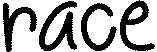

In [123]:
image = Image.open(train_dataset.root_dir + train_df['file_name'][0]).convert("RGB")
image

In [124]:
labels = encoding['labels']
labels[labels == -100] = processor.tokenizer.pad_token_id
label_str = processor.decode(labels, skip_special_tokens=True)
print(label_str)

race


In [125]:
from transformers import VisionEncoderDecoderModel

model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-stage1")

Loading weights:   0%|          | 0/476 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-stage1
Key                                                 | Status     | 
----------------------------------------------------+------------+-
decoder.model.decoder.embed_positions._float_tensor | UNEXPECTED | 
encoder.pooler.dense.bias                           | MISSING    | 
encoder.pooler.dense.weight                         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [126]:
model

VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (q_proj): Linear(in_features=768, out_features=768, bias=False)
          (k_proj): Linear(in_features=768, out_features=768, bias=False)
          (v_proj): Linear(in_features=768, out_features=768, bias=False)
          (o_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layernorm_before): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (layernorm_after): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (mlp): ViTMLP(
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=30

In [127]:
for name, param in model.named_parameters():
    param.requires_grad = True
    #print(name)
    # if name=='decoder.output_projection.weight':
    #     param.requires_grad = True


In [128]:
# set special tokens used for creating the decoder_input_ids from the labels
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id = processor.tokenizer.pad_token_id
# make sure vocab size is set correctly
model.config.vocab_size = model.config.decoder.vocab_size

# set beam search parameters
model.config.eos_token_id = processor.tokenizer.sep_token_id
model.config.max_length = 64
model.config.early_stopping = True
model.config.no_repeat_ngram_size = 3
model.config.length_penalty = 2.0
model.config.num_beams = 4

In [129]:
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments

training_args = Seq2SeqTrainingArguments(
    predict_with_generate=True,
    eval_strategy="steps",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    fp16=True,
    output_dir="./",
    logging_steps=2,
    save_steps=1000,
    eval_steps=100,
    num_train_epochs = 10
)

In [130]:
# !pip install evaluate jiwer

In [131]:
import evaluate

In [132]:


cer_metric = evaluate.load("cer")

In [133]:
def compute_metrics(pred):
    labels_ids = pred.label_ids
    pred_ids = pred.predictions

    pred_str = processor.batch_decode(pred_ids, skip_special_tokens=True)
    labels_ids[labels_ids == -100] = processor.tokenizer.pad_token_id
    label_str = processor.batch_decode(labels_ids, skip_special_tokens=True)

    cer = cer_metric.compute(predictions=pred_str, references=label_str)

    return {"cer": cer}

In [134]:
import torch
from transformers import VisionEncoderDecoderModel, Seq2SeqTrainer

# 1. Force the model to load fully into memory (avoiding the meta tensor trap)
# Ensure device_map='auto' or low_cpu_mem_usage=True are NOT included here!
model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-handwritten")

# 2. Explicitly push the entire model onto your GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# 3. Use our lightweight custom collator that handles both keys cleanly
def custom_tr_ocr_collator(features):
    pixel_values = torch.stack([f["pixel_values"] for f in features]).to(device)
    labels = [f["labels"] for f in features]

    padded_labels = torch.nn.utils.rnn.pad_sequence(
        labels,
        batch_first=True,
        padding_value=-100
    ).to(device)

    # Generate decoder_input_ids safely on the correct device
    decoder_start_token_id = model.config.decoder_start_token_id
    shifted_labels = padded_labels.clone()
    shifted_labels[shifted_labels == -100] = processor.tokenizer.pad_token_id

    decoder_input_ids = torch.full(
        (shifted_labels.shape[0], 1),
        decoder_start_token_id,
        dtype=torch.long,
        device=device
    )
    decoder_input_ids = torch.cat([decoder_input_ids, shifted_labels[:, :-1]], dim=-1)

    return {
        "pixel_values": pixel_values,
        "labels": padded_labels,
        "decoder_input_ids": decoder_input_ids
    }

# 4. Re-initialize the trainer with the fully loaded model
trainer = Seq2SeqTrainer(
    model=model,
    processing_class=processor,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=custom_tr_ocr_collator,
)

# 5. Fire it up!
trainer.train()

KeyboardInterrupt: 

In [ ]:
# Load and preprocess the image
image = Image.open("/content/synthetic-data/American@3WPOqS.png").convert("RGB")
pixel_values = processor(image, return_tensors="pt").pixel_values

# Perform inference
model.eval()  # Set the model to evaluation mode
with torch.no_grad():
    generated_ids = model.generate(pixel_values.to(device))

# Decode the generated ids to text
predicted_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

print("Predicted Text:", predicted_text)